
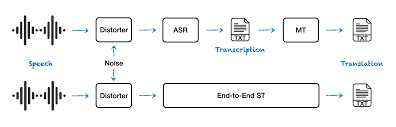

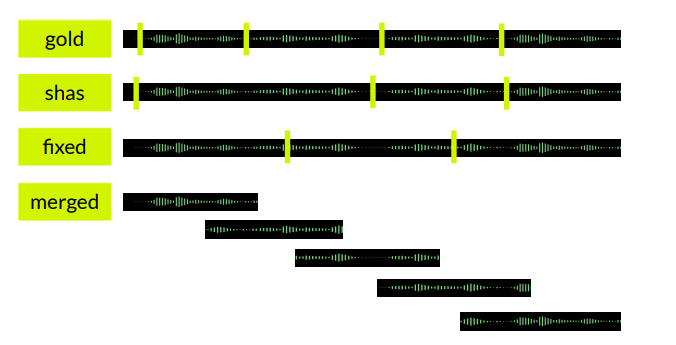

# 1) Intro

    .
    
                                                 Will be added soon :)
    
    
    .

************# Getting Starting

In [ ]:
# !pip install torchinfo
# !pip install pyarabic
# !pip install tokenizers
# !pip install librosa
# !pip install lightning


## =======================================

#  

##============================================

# !pip install --force-reinstall -v "ipywidgets == 7.7.2"


# !pip install https://storage.googleapis.com/tpu-pytorch/wheels/cuda/112/torch_xla-1.13-cp37-cp37m-linux_x86_64.whl
# !pip install cloud-tpu-client==0.10 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.13-cp37-cp37m-linux_x86_64.whl

In [ ]:
!pip3 install https://storage.googleapis.com/tpu-pytorch/wheels/cuda/112/torch_xla-nightly-cp37-cp37-linux_x86_64.whl

In [28]:
!conda --version


# !conda update -n base conda --yes


conda 22.9.0


In [4]:
!conda env list                

# conda environments:
#
base                     /opt/conda



In [5]:
# !conda install pytorch torchvision torchaudio cudatoolkit=11.4.1 -c pytorch
# !conda remove numba
# !pip uninstall numba
# !conda install -c conda-forge numba

# !apt-get update && apt-get install -y libsndfile1 ffmpeg
# !pip install Cython
# !conda install pytorch-lightning -c conda-forge

In [33]:
import torch_xla
print(torch_xla.__version__)


ImportError: /opt/conda/lib/python3.7/site-packages/_XLAC.cpython-37m-x86_64-linux-gnu.so: undefined symbol: _ZNK5torch8autograd4Node4nameEv

In [ ]:
# !pip uninstall torch_xla==1.13 --yes
# !pip install torch torchvision torchaudio
# !pip list | grep torch

In [ ]:
# !conda list | grep torch

In [7]:
import os                      
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import librosa
from yaml import CLoader
from os.path import join
from tqdm.notebook import tqdm
import math
import random
%matplotlib inline

In [8]:
import torch
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torchinfo import summary
from s2t_utils import TokenHandler
print(torch.__version__)

import sys
print(sys.version)

1.13.0
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:53) 
[GCC 9.4.0]


In [9]:
for i in tqdm(range(10)):
    i = i

  0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
def setup():
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

setup()

In [11]:
ar_json_path = '/kaggle/input/helper-for-s2t/tokenizers/ar_tokenizer.json'
en_json_path = '/kaggle/input/helper-for-s2t/tokenizers/en_tokenizer.json'
ar_tokenizer = TokenHandler(ar_json_path, 'ar')
en_tokenizer = TokenHandler(en_json_path, 'en')

In [12]:
def get_yaml_data(path):
    with open(path) as f:
        data = yaml.load(f, Loader=CLoader)
        return data    
    
def get_text_data(path):
    with open(path, 'rt', encoding='utf-8', errors='ignors') as f:
        return f.readlines()
    
def create_split_data(en, ar, yaml, wav_dir, train=False):
    print('read yaml data. --')
    data = get_yaml_data(yaml)
    data = pd.DataFrame.from_records(data)
    data['wav'] = data['wav'].apply(lambda x: os.path.join(wav_dir, x))
    print('read en text. --')
    data['en'] = get_text_data(en)
    
    print('read ar text. --')
    data['ar'] = get_text_data(ar)
    
    
    
    if train:
        data = data[data['duration'] > 2.0]
        data = data[data['duration'] < 30.0]
        data = data.reset_index(drop=True)
        
    data = data.sample(frac=1).reset_index(drop=True)                     # shuffle data before return it
    return data

In [13]:
train_data = create_split_data('/kaggle/input/must-c-en-ar/train/txt/train_en.txt',
                               '/kaggle/input/must-c-en-ar/train/txt/train_ar.txt',
                               '/kaggle/input/must-c-en-ar/train/txt/train.yaml',
                               '/kaggle/input/must-c-en-ar/train/wav',
                                True)

dev_data = create_split_data('/kaggle/input/must-c-en-ar/dev/txt/dev.en',
                               '/kaggle/input/must-c-en-ar/dev/txt/dev.ar',
                               '/kaggle/input/must-c-en-ar/dev/txt/dev.yaml',
                               '/kaggle/input/must-c-en-ar/dev/wav')

read yaml data. --
read en text. --
read ar text. --
read yaml data. --
read en text. --
read ar text. --


In [14]:
train_data.head()

,duration,offset,speaker_id,wav,en,ar
0,16.869999,261.480000,spk.1945,/kaggle/input/must-c-en-ar/train/wav/ted_1945.wav,"If a female gets too many stab wounds, or if a...","هم يطعنونها في أي مكان في جسدها, والحيوان المن..."
1,6.700001,612.279999,spk.590,/kaggle/input/must-c-en-ar/train/wav/ted_590.wav,These are some images from a project of mine t...,هذه هي بعض الصور من مشروع لي يسمى (كايمايريكا)...
2,11.260000,425.340000,spk.1118,/kaggle/input/must-c-en-ar/train/wav/ted_1118.wav,"When very large stars die, they create tempera...","عندما تموت النجوم ذوات الأحجام الضخمة, تولد حر..."
3,5.100000,243.469999,spk.199,/kaggle/input/must-c-en-ar/train/wav/ted_199.wav,"AB: Yes? Oh, one more, one more three-digit nu...","آرثر بينجامين: صحيح? تماما, رقم آخر, رقم آخر م..."
4,8.470001,179.609999,spk.2559,/kaggle/input/must-c-en-ar/train/wav/ted_2559.wav,"And I care so much about this question, that I...","ويهمني كثيرا هذا السؤال, أعمل في مؤسسة غير ربح..."


In [15]:
# train_visu = pd.DataFrame()
# train_visu['ar_tokens'] = train_data['ar'].apply(lambda x: len(ar_tokenizer(x)))
# train_visu['ar_words'] = train_data['ar'].apply(lambda x: len(x.split()))
# train_visu['en_tokens'] = train_data['en'].apply(lambda x: len(en_tokenizer(x)))
# train_visu['en_words'] = train_data['en'].apply(lambda x: len(x.split()))
# train_visu['duration'] = train_data['duration']
# # train_visu['spk_id'] = train_data['speaker_id'].apply(lambda x: int(x.split('.')[1]))

In [16]:
# train_visu.describe()

In [17]:
# (train_visu['duration'] / train_visu['en_tokens']).describe()

In [18]:
# plt.plot((train_visu['ar_tokens'] / train_visu['duration']).values, )
# plt.show()

In [19]:
# f, ax = plt.subplots(3, 2, figsize=(16, 8), sharex=False,)
# ax[0, 0].hist(train_visu['ar_words'].values, range(0, 150))
# ax[0, 0].set_title(f'ar_words min={train_visu["ar_words"].values.min()}  and max={train_visu["ar_words"].values.max()}')

# ax[0, 1].hist(train_visu['ar_tokens'].values, range(0, 150))
# ax[0, 1].set_title(f'ar_tokens min={train_visu["ar_tokens"].values.min()}  and max={train_visu["ar_tokens"].values.max()}')

# ax[1, 0].hist(train_visu['en_words'].values, range(0, 150))
# ax[1, 0].set_title(f'en_words min={train_visu["en_words"].values.min()}  and max={train_visu["en_words"].values.max()}')

# ax[1, 1].hist(train_visu['en_tokens'].values, range(0, 150))
# ax[1, 1].set_title(f'en_tokens min={train_visu["en_tokens"].values.min()}  and max={train_visu["en_tokens"].values.max()}')

# # ax[2, 0].hist(train_visu['spk_id'].values)
# # ax[2, 0].set_title(f'spk_id min={train_visu["spk_id"].values.min()}  and max={train_visu["spk_id"].values.max()}')

# ax[2, 1].hist(train_visu['duration'].values)
# ax[2, 1].set_title(f'duration min={train_visu["duration"].values.min()}  and max={train_visu["duration"].values.max()}')

# plt.show()

In [20]:
class MyDataset(Dataset):
    def __init__(self, data,  ar_token, ar_size=110, wave_size=30, sr=16000): #en_token,
        self.data      = data
#         self.en_token = en_token
        self.data = self.data.sample(frac=1).reset_index(drop=True)
        self.ar_token  = ar_token
        self.ar_size   = ar_size
        self.wave_size = wave_size
        self.sr        = sr
            
    def __getitem__(self, idx):
        
        du, of, speaker_id, wav_path, en, ar = self.data.iloc[idx]
        
        of = int(of * self.sr)
        du = int(du * self.sr)
        
        wave, _ = torchaudio.load(wav_path, frame_offset=of, num_frames=du)
        
        if wave.size(1) < self.sr * self.wave_size:
            wave = nn.functional.pad(wave,[0, self.sr * self.wave_size - wave.size(1)])
        elif wave.size(1) > self.sr * self.wave_size:
            wave    = wave[:, :self.wave_size*self.sr]
        else: None
#         en = self.en_token.encode_line(en)
        ar = self.ar_token(ar, self.ar_size)
    
        ar = torch.tensor(ar).long()
        
        return wave, ar
        
    def __len__(self):
        return len(self.data)

# Helper for model.

In [21]:
class Encoder(pl.LightningModule):
    def __init__(self, d_model, nhead, dropout=0.3, batch_first=True):
        super(Encoder, self).__init__()
        
        self.d_model  = d_model
        
        self.pre_norm = nn.LayerNorm(d_model)
        
        self.mha      = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, 
                                               bias=True, batch_first=batch_first)
        
        self.res_front = nn.Sequential(nn.Conv1d(1, 3, 7, 1, padding='same'),  
                                       nn.ReLU(),
                                       nn.Conv1d(3, 3, 5, 1, padding='same'),  
                                       nn.Conv1d(3, 5, 3, 1, padding='same'),  
                                       nn.LeakyReLU(0.3))
        
        
        self.res_back  = nn.Linear(self.d_model* 5, self.d_model, bias=False)


        self.ffn       = nn.Sequential(nn.LayerNorm(d_model),
                                       nn.Linear(self.d_model, self.d_model*2),
                                       nn.LeakyReLU(0.2),
                                       nn.Dropout(0.3),
                                       nn.Linear(self.d_model*2, self.d_model),
                                       nn.LeakyReLU(0.2),
                                       nn.Dropout(0.15))
        
    def forward(self, x, padding_mask=None, need_weights=False, attn_mask=None, training=False):  #
        x = self.pre_norm(x)
        att_out, att_weights = self.mha(x, x, x, padding_mask, need_weights, attn_mask)
        
        B, T, D = x.size()
        x = x.view(B*T, 1, D)
        x = self.res_front(x)
        
        x = x.view(B, T, 5*D)
        x = F.dropout(x, 0.15, training=training)
        x = self.res_back(x)
        
        att_out = att_out + x; del x
        att_out = self.ffn(att_out)
        
        if need_weights:
            return att_out, att_weights
        
        return att_out
        
        

In [22]:
class Decoder(pl.LightningModule):
    def __init__(self, d_model, nhead, dropout=0.3, batch_first=True):
        super(Decoder, self).__init__()
        
        self.d_model   = d_model
        
        self.pre_norm1 = nn.LayerNorm(d_model)
        
        self.smha      = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, 
                                               bias=True, batch_first=batch_first)
        
        self.res_front = nn.Sequential(nn.Conv1d(1, 3, 7, 1, padding='same'),  
                                       nn.ReLU(True),
                                       nn.Conv1d(3, 3, 5, 1, padding='same'),  
                                       nn.Conv1d(3, 5, 3, 1, padding='same'),  
                                       nn.LeakyReLU(0.3))
        
        self.res_back  = nn.Linear(self.d_model* 5, self.d_model, bias=False)


        self.pre_norm2 = nn.LayerNorm(d_model)
        
        self.cmha      = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead*2, dropout=dropout, 
                                               bias=True, batch_first=batch_first)
        
        self.ffn       = nn.Sequential(nn.LayerNorm(d_model),
                                       nn.Linear(self.d_model, self.d_model*2),
                                       nn.LeakyReLU(0.2),
                                       nn.Dropout(0.3, True),
                                       nn.Linear(self.d_model*2, self.d_model),
                                       nn.LeakyReLU(0.2),
                                       nn.Dropout(0.15, True))
        
    def forward(self, query, key, q_padding_mask=None, k_padding_mask=None, need_weights=False, attn_mask=None, training=False):
        
        query = self.pre_norm1(query)
        att_out, _ = self.smha(query, query, query, key_padding_mask=q_padding_mask, need_weights=False, attn_mask=attn_mask)
        
        B, T, D = query.size()
        query = query.view(B*T, 1, D)
        query = self.res_front(query)
        
        query = query.view(B, T, 5*D)
        query = F.dropout(query, 0.15, training=training)

        query = self.res_back(query)
        query = att_out + query; del att_out
        
        
        query = self.pre_norm2(query)
        att_out, att_weight = self.cmha(query, key, key, k_padding_mask, need_weights=need_weights, attn_mask=None)
        
        att_out = att_out + query; del query
        att_out = self.ffn(att_out)
        
        if need_weights:
            return att_out, att_weights
        
        return att_out

# Feature Extractor Block and segmentor

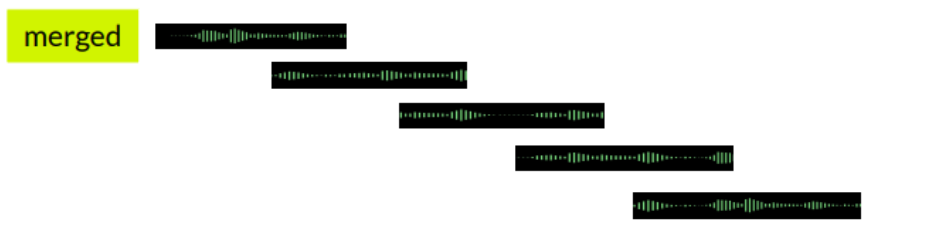

In [23]:
class CompactWave(pl.LightningModule):
    def __init__(self, sr, frame_size, frame_stride, out_dim=512):
        assert frame_size >= 2000, "the frame size minimum should be greater than or equal 2000"
        assert sr == 16000, "suported sample rate is 16000"
        super(CompactWave, self).__init__()
        self.sr = sr
        self.frame_size  = frame_size                                           
        self.frame_stride = frame_stride
        self.out_dim = out_dim
        pram_per_layer = [(13, 1, 0, 3), (11, 1, 0, 2), (11, 1, 0, 2), (2, 2, 0, 1),
                          (7, 1, 0, 1), (7, 2, 0, 1), (7, 1, 0, 2), (3, 3, 0, 1),
                          (5, 2, 0, 1), (5, 2, 0, 1), (5, 2, 0, 2), (2, 1, 0, 1),   
                          (3, 1, 0, 1), (3, 2, 0, 1), (3, 1, 0, 1), (2, 2, 0, 1)]
    
        self.conv_block_1 = nn.Sequential(nn.Conv1d(1, 4, 11, 1, dilation=3),  
                                          nn.ReLU(),
                                          nn.Conv1d(4, 4, 11, 1, dilation=2),  
                                          nn.Conv1d(4, 8, 11, 1, dilation=2),  
                                          nn.ReLU(),
                                          nn.MaxPool1d(2, 2),                   
                                          nn.BatchNorm1d(8))
        
               
        self.conv_block_2 = nn.Sequential(nn.Conv1d(8, 11, 7, 1, dilation=1),  
                                          nn.ReLU(),
                                          nn.Conv1d(11, 11, 7, 2, dilation=1),  
                                          nn.Conv1d(11, 14, 7, 1, dilation=2),  
                                          nn.ReLU(),
                                          nn.MaxPool1d(3, 3),                  
                                          nn.BatchNorm1d(14))
        
               
        self.conv_block_3 = nn.Sequential(nn.Conv1d(14, 18, 5, 2, dilation=1),  
                                          nn.ReLU(),
                                          nn.Conv1d(18, 18, 5, 2, dilation=1),  
                                          nn.Conv1d(18, 20, 5, 2, dilation=2), 
                                          nn.ReLU(),
                                          nn.MaxPool1d(2, 1),                  
                                          nn.BatchNorm1d(20))
        
               
        self.conv_block_4 = nn.Sequential(nn.Conv1d(20, 23, 3, 1, dilation=1),  
                                          nn.ReLU(),
                                          nn.Conv1d(23, 23, 3, 2, dilation=1),  
                                          nn.Conv1d(23, 25, 3, 1, dilation=1),  
                                          nn.ReLU(),
                                          nn.MaxPool1d(2, 2),                   
                                          nn.BatchNorm1d(25))
        
        out_shape = self.frame_size
        for p in pram_per_layer:
            out_shape = self._conv_output_length(out_shape, *p)
        
        self.projection = nn.Sequential(nn.Linear(out_shape, out_dim//2),
                                        nn.Dropout(0.1),
                                        nn.LeakyReLU(0.5),
                                        nn.Linear(out_dim//2, out_dim))
        
        self.norm = nn.BatchNorm1d(out_dim)
        
        
        
    def _conv_output_length(self, length_in, kernel_size, stride=1, padding=0, dilation=1):
        return (length_in + 2 * padding - dilation * (kernel_size - 1) - 1) // stride + 1
        
#     @torch.cuda.amp.autocast()
    def forward(self, waves, training=False):
        # ensure that all chunks will be the same size
        
        waves = self.__pad_wave(waves)
        # convert the the wave into overlabing chunks
        waves = waves.unfold(dimension = 2, size=self.frame_size, step=self.frame_stride).transpose(2, 1)
        B, chunks, c, seq_len = waves.size()
        waves = waves.contiguous().view(B*chunks, c, seq_len)
        
        waves = self.conv_block_1(waves)
        waves = self.conv_block_2(waves)
        waves = self.conv_block_3(waves)
        waves = self.conv_block_4(waves)
        waves = waves.view(-1, waves.size(-1)) #view(B * chunks * c, waves.size(-1))
        
        waves = self.projection(waves)
        waves = self.norm(waves).view(B, -1, waves.size(-1))
            
        return waves
        
    def __pad_wave(self, wave: torch.TensorType):
        """Only supported shapes (B, C, Wave_size) or (B, Wave_size) or (Wave_size, ) for unbatched
        """
        
        B, C, w_len = 1, 1, None
        if not isinstance(wave, torch.Tensor):
            wave = torch.tensor(wave, dtype=torch.float32)
        wave = wave.type(torch.float32)
        if wave.dim() == 3:
            B, C, w_len = wave.size()
        elif wave.dim() == 2:
            B, w_len = wave.size()
        elif wave.dim() == 1:
            w_len, = wave.size()
            wave = wave.unsqueeze(0)

        else:
            raise ValueError(f'expected number of dims is 1 for unbatched and 2 for batched but you provide {wave.dim()}')
        
        assert w_len >= self.frame_size, f'vrey short wave lenght. minimum wave lenght is {self.frame_size}'
        assert C == 1, f'only support mono wave at this time. Expected num of channels is {1} but given {C}'
        
        wave = wave.reshape(B, C, w_len)
        num_frames = int(math.ceil(float(abs(w_len - self.frame_size)) / self.frame_stride))
        plus_len = (num_frames * self.frame_stride + self.frame_size) - w_len
        wave = F.pad(wave, [0, plus_len], "constant", 0) 
        return wave

# Model

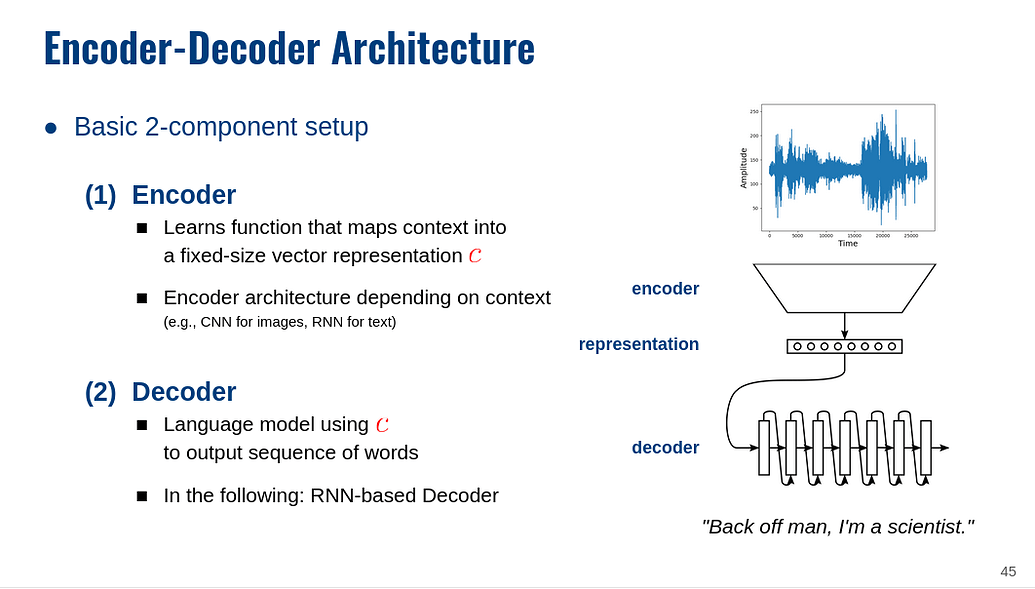

**[beam search code](https://github.com/jarobyte91/pytorch_beam_search/blob/master/src/pytorch_beam_search/seq2seq/search_algorithms.py)**

In [24]:
class ArTextizer(pl.LightningModule):
    def __init__(self, voc_size, special: dict, sr=16000, frame_size=2000, frame_stride=1600, out_dim=512):
        super(ArTextizer, self).__init__()
        
        self.voc      = voc_size
        self.special  = special
        self.out_dim  = out_dim
        self.wave_enc = CompactWave(sr, frame_size, frame_stride, out_dim)
        
        self.enc = nn.ModuleList([Encoder(d_model=out_dim, nhead=16, dropout=0.3, batch_first=True) for _ in range(4)])
        
        self.word2vec = nn.Embedding(num_embeddings=voc_size, embedding_dim=out_dim, padding_idx=self.special['pad']) #, scale_grad_by_freq=True

        self.dec = nn.ModuleList([Decoder(d_model=512, nhead=16, dropout=0.15, batch_first=True) for _ in range(4)])
        
        self.out_head = nn.Sequential(nn.Dropout(0.2, True),
                                      nn.Linear(out_dim, voc_size//2),
                                      nn.LayerNorm(voc_size//2),
                                      nn.Dropout(0.2, True),
                                      nn.Linear(voc_size//2, voc_size))
        
        
        
        
    def sin_soidal(self, length: int, depth: int, n: int=10000):
        '''create positionalemppeding matrix
        @params:
                length:  Max number of tokens in as sentence that the model will deal with it during inference.
                depth:   Empeddingdim
                n:       Hyper-parameter from the paper 
        '''

        positions = torch.arange(length).view(-1, 1)    # (seq, 1)  [0, 1, 2, 3 ... length-1]

        depths = torch.arange(depth).view(1, -1) / depth   # (1, depth) [0 / depth, 1 / depth, 2/depth, 3/depth ... length-1/depth]

        angle_rates = 1 / (n**depths)             # (1, depth)

        angle_rads = positions * angle_rates      # (pos, depth)

        angle_rads[:, 0::2] = torch.sin(angle_rads[:, 0::2])

        # apply cos to odd indices in the array; 2i+1
        angle_rads[:, 1::2] = torch.cos(angle_rads[:, 1::2])
    #         print(angle_rads.shape)
        return angle_rads.float()    

    
    def forward(self, x, max_len=20, beam_width=5, tempreture=1.0, training=False):
        
        x   = self.wave_enc(x, False)
        pos = self.sin_soidal(x.size(1), self.out_dim).to(x.device)
        x   = x + pos 
        for layer in self.enc:
            x  = layer(x, training=False)
        ids = self.beam_search(x, max_len=20, beam_width=5, tempreture=1.0)
        return ids
    
        
    def get_next_logits(self, pre, context):
        pre = self.word2vec(pre)
        pos = self.sin_soidal(pre.size(0), self.out_dim).to(context.device)
        pre = pre + pos 

        for layer in self.dec:
            pre = layer(pre, context, training=False)

        pre = self.out_head(pre[0, -1])
        return pre
        
    def beam_search(self, context, max_len=20, beam_width=5, tempreture=1.0):
        """
        Implements Beam Search to compute the output with the sequences given in X. The method can compute 
        several outputs in parallel with the first dimension of X.
        ----------    
        @Parameters:
                    context:      FloatTensor of shape (BatchSize, TimeStep, EmpedDim). The transformer encoder output.
                    max_len:      int. The max number of tokens to append to return.
                    beam_width:   int. The number of candidates to keep in the search.
                    batch_size:   int. The batch size of the inner loop of the method, which relies on the beam width. 
                    progress_bar: int. Shows a tqdm progress bar, useful for tracking progress with large tensors. Ranges from 0 to 2.
        @Returns
                    Y: LongTensor of shape (examples, length + predictions)
                        The output sequences.
                    probabilities: FloatTensor of length examples
                        The estimated log-probabilities for the output sequences. They are computed by iteratively adding the 
                        probability of the next token at every step.
        """
        
        best_beams = [(1.0, self.special['cls'])]

        for _ in range(max_len):
            beam_probs = []
            beam_next_elements = []

            # for each beam, get the next step's distribution, and take the top k
            for prob, path in best_beams:
                dist = self.get_next_logits(path, context).log_softmax()
                top_prob, top_ids = torch.topk(dist, min(len(dist), beam_width))
                beam_probs.append(prob + top_prob)
                beam_next_elements.append(top_ids)

            # combine all beams' best, and take the top k
            beam_probs = torch.cat(beam_probs)
            k = min(len(beam_probs), beam_width)
            top_prob, top_ids = torch.topk(beam_probs, k)
            top_prob = torch.exp(top_prob*tempreture)
            best_beam_next_elements = torch.cat(beam_next_elements)[top_ids]

            # set the new best beams
            # concat the next elements to the end of their trajectories

            best_beams = [(top_prob[i], torch.cat([best_beams[top_ids[i] // beam_width][1], best_beam_next_elements[i].view(1)])) 
                          for i in range(k)]
        
        result = dict()
        for i in range(beam_width):
            result[f'hybothies:1'] = {'prob': best_beams[i][0], 'ids': best_beams[i][1]}
            
        return result

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        # it is independent of forward
        teacher_force = 0.3
        x, y = batch
        y_in, y_out = y[:, :-1].clone(), y[:, 1:].clone(); del y
        x  = self.wave_enc(x)

        x = x + self.sin_soidal(x.size(1), self.out_dim).to(x.device)
        for i in range(4):
            x  = self.enc[i](x, training=True)
            
        pad_mask = y_in == self.special['pad']
        
        mask   = torch.triu(torch.ones(y_in.size(1), y_in.size(1)) * -1e6, diagonal=1).to(x.device)
        y_in = self.word2vec(y_in)
        y_in = y_in + self.sin_soidal(y_in.size(1), self.out_dim).to(x.device)

        for i in range(4):
            y_in  = self.dec[i](y_in, x, q_padding_mask=pad_mask.to(x.device), attn_mask=mask, training=True)
        y_in = self.out_head(y_in)
        
        loss = F.cross_entropy(y_in.view(-1, self.voc), y_out.view(-1)) * (1+teacher_force)
        acc  = (y_out == y_in.argmax(-1)).float().mean() * teacher_force
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss 
    
    
    def validation_step(self, batch, batch_idx):
        # this is the validation loop
        x, y = batch
        y_in, y_out = y[:, :-1].clone(), y[:, 1:].clone(); del y
        x  = self.wave_enc(x)

        x = x + self.sin_soidal(x.size(1), self.out_dim).to(x.device)
        for i in range(4):
            x  = self.enc[i](x, training=True)
            
        pad_mask = y_in == self.special['pad']
        
        mask   = torch.triu(torch.ones(y_in.size(1), y_in.size(1)) * -1e6, diagonal=1).to(x.device)
        y_in = self.word2vec(y_in)
        y_in = y_in + self.sin_soidal(y_in.size(1), self.out_dim).to(x.device) 

        for i in range(4):
            y_in  = self.dec[i](y_in, x, q_padding_mask=pad_mask.to(x.device), attn_mask=mask, training=True)
        y_in = self.out_head(y_in)
        
        loss = F.cross_entropy(y_in.view(-1, self.voc), y_out.view(-1))
        acc  = (y_out == y_in.argmax(-1)).float().mean()
        self.log("val_loss", loss,on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_acc", acc, on_step=True, on_epoch=True, prog_bar=True, logger=True)

        
    def test_step(self, batch, batch_idx):  
        x, y = batch
        y_in, y_out = y[:, :-1].clone(), y[:, 1:].clone(); del y
        y_in = self(x)
        loss = F.cross_entropy(y_in.view(-1, self.voc), y_out.view(-1))
        self.log("test_loss", loss)
        
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3)
        return optimizer
    
        

In [25]:
special = {'pad': ar_tokenizer.get_id('<PAD>'),
               'cls': ar_tokenizer.get_id('<CLS>'),
               'end': ar_tokenizer.get_id('<SEP>'),
               'max': 150}
model = ArTextizer(12000, special, sr=16000, frame_size=16000*3, frame_stride=16000*2, out_dim=512)

In [26]:
import torch_xla
train = MyDataset(train_data, ar_tokenizer, ar_size=110, wave_size=30, sr=16000)
dev = MyDataset(dev_data, ar_tokenizer, ar_size=110, wave_size=30, sr=16000)
train_loader = DataLoader(train, batch_size=5, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

dev_loader = DataLoader(dev, batch_size=5, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

trainer = pl.Trainer( accelerator='gpu', devices=1, max_epochs=5, accumulate_grad_batches=7, enable_model_summary=True)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=dev_loader)

ModuleNotFoundError: No module named 'torch_xla'

In [ ]:
# !pip install -U torch_xla

In [ ]:
# class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
#     def __init__(self, optimizer, warmup, max_iters):
#         self.warmup = warmup
#         self.max_num_iters = max_iters
#         super().__init__(optimizer)

#     def get_lr(self):
#         lr_factor = self.get_lr_factor(epoch=self.last_epoch)
#         return [base_lr * lr_factor for base_lr in self.base_lrs]

#     def get_lr_factor(self, epoch):
#         lr_factor = 0.5 * (1 + np.cos(np.pi * epoch / self.max_num_iters))
#         if epoch <= self.warmup:
#             lr_factor *= epoch * 1.0 / self.warmup
#         return lr_factor
    

# class Trainer:
#     def __init__(self, model, tokenizer, rank, tll, vll):
#         self.gpu_id = rank
#         self.model     = model
#         self.tokenizer = tokenizer
#         self.tll = tll
#         self.vll = vll
        
#         self._setup()
        
#     def _setup(self):
#         self.model = DDP(self.model, device_ids=[self.gpu_id], output_device=self.gpu_id)
#         self.model.train()
# #         torch.autograd.set_detect_anomaly(True)
#         self.lossFun = nn.CrossEntropyLoss()
#         self.optm    = torch.optim.AdamW(self.model.parameters(), lr=3e-3, weight_decay=0.3)
#         self.LR_s    = CosineWarmupScheduler(self.optm, 10000, 100000)
        
#         self.train_loss = []
#         self.train_acc  = []
#         self.val_loss   = []
#         self.val_acc    = []
        

        
#     def train_step(self, train_batch):
#         self.model.train()
#         waves, ids = train_batch; del train_batch
#         waves, ids = waves.to(self.gpu_id), ids.to(self.gpu_id)
#         ids_hat    = self.model(waves=waves, target=ids[:, :-1], teacher_force=0.8, training=True); del waves
#         loss = self.lossFun(ids_hat.view(-1, 12000), ids[:, 1:].contiguous().view(-1))
#         acc  = (ids[:, 1:] == ids_hat.argmax(-1)).float().mean()
#         return loss, acc
     
#     @torch.inference_mode()
#     def val_step(self, val_batch):
#         self.model.eval()
#         waves, ids = val_batch; del val_batch
#         waves, ids = waves.to(self.gpu_id), ids.to(self.gpu_id)
#         ids_hat    = self.model(waves=waves, target=ids[:, :-1], teacher_force=1.0, training=False); del waves
#         loss = self.lossFun(ids_hat.view(-1, 12000), ids[:, 1:].contiguous().view(-1))
#         acc  = (ids[:, 1:] == ids_hat.argmax(-1)).float().mean()
#         return loss, acc
    
#     def show_one_sample_with_blue_score(self, wave, ground_truth: str):
#         self.model.eval()
#         waves = waves.to(self.gpu_id)
#         output = self.model.transcribe(wave)
        
#         output = str(self.tokenizer.decode(output.cpu().detach().numpy().tolist()))
#         bs = bleu_score(output.split(), ground_truth.split())
#         print(f'\nGround Truth:    {ground_truth}')
#         print(f'\nModel Predict:   {output}')
#         print(f'\nWith Blue Score: {bs}')

        
        
#     def train(self, train_loader, val_loader, selected_sample, epochs=1, accum_iter=1):
        
#         for i in range(epochs):
#             ll         = self.tll
#             batch_loss = 0
#             batch_acc  = 0
#             acc_loss   = 0
            
#             train_loader.sampler.set_epoch(i)
#             ppr = tqdm(enumerate(train_loader), total=ll)
            
#             for batch_idx, train_batch in ppr:
#                 ppr.set_description(f'Epoch: {i + 1:3d},  TrainBatch: {batch_idx+1} / {ll}\t')
#                 loss, acc  = self.train_step(train_batch)
#                 acc_loss  += loss 
                
                
                
#                 if not (batch_idx + 1) % accum_iter:
#                     acc_loss = acc_loss / accum_iter
#                     acc_loss.backward(retain_graph=True)
#                     nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=10, norm_type=2.0)
# #                     xm.optimizer_step(self.optm)
#                     self.optm.step()
#                     self.optm.zero_grad()
#                     self.LR_s.step()
#                     acc_loss = 0
                    
#                 batch_loss += loss.item() / ll
#                 batch_acc  += acc.item() / ll
#                 ppr.set_postfix_str(f'\t\tLoss: {batch_loss:0.5f},  Acc: {batch_acc:0.5f}\t')
            
#             self.train_loss.append(batch_loss)
#             self.train_acc.append(batch_acc)
            
#             ll         = self.vll
#             batch_loss = 0
#             batch_acc  = 0
# #             acc_loss   = 0
#             val_loader.sampler.set_epoch(i)
#             ppr = tqdm(enumerate(val_loader), total=ll)

#             for batch_idx, val_batch in ppr:
#                 ppr.set_description(f'Epoch: {i + 1:3d}, ValBatch: {batch_idx+1} / {ll}\t.')
#                 loss, acc   = self.train_step(val_batch)
# #                 acc_loss   += loss / accum_iter
#                 batch_loss += loss.item() / ll
#                 batch_acc  += acc.item() / ll
#                 ppr.set_postfix_str(f'.\t\tValLoss: {loss.item():0.5f},  ValAcc: {acc.item():0.5f}\t.')
# #                 print('done')
            
#             self.val_loss.append(batch_loss)
#             self.val_acc.append(acc_loss)
            
            
#             show_one_sample_with_blue_score(*selected_sample)
            
#             self.save_checkpoint(i)
            
        
#         history = {'loss': self.train_loss,
#                    'val_loss': self.val_loss,
#                    'acc': self.train_acc,
#                    'val_acc': self.val_acc
#                   }
            
#         return self.model, history

#     def save_checkpoint(self, idx):
#         if self.gpu_id == 0:
#             os.makedirs('saved_model', exist_ok=True)
#             torch.save(self.model.module.state_dict(), f'STT_{idx}.pt')
    

In [ ]:
# train = MyDataset(train_data, ar_tokenizer, ar_size=100, wave_size=22, sr=16000)
# dev = MyDataset(dev_data, ar_tokenizer, ar_size=100, wave_size=22, sr=16000)

# wave, ar = dev.__getitem__(5)
# print(wave.size())
# print(ar.size())
# ar = str(ar_tokenizer.decode(ar.cpu().detach().numpy().tolist()))
# print(ar)
# selected_sample = (wave, ar)

# def main_gpu(rank, world_size, total_epochs):
#     ddp_setup(rank, world_size)
    
#     train_sampler = DistributedSampler(train, num_replicas=world_size, rank=rank, shuffle=True)
#     train_loader = DataLoader(train, batch_size=2, shuffle=False, num_workers=, pin_memory=True, drop_last=True, sampler=train_sampler)
#     tll = len(train_loader)

#     dev_sampler = DistributedSampler(dev, num_replicas=world_size, rank=rank, shuffle=True)
#     dev_loader = DataLoader(dev, batch_size=2, shuffle=False, num_workers=0, pin_memory=True, drop_last=True, sampler=dev_sampler)
#     vll = len(dev_loader)
    
#     special = {'pad': ar_tokenizer.get_id('<PAD>'),
#                'cls': ar_tokenizer.get_id('<CLS>'),
#                'end': ar_tokenizer.get_id('<SEP>'),
#                'max': 150}
#     model = ArTextizer(12000, special, sr=16000, frame_size=20000, frame_stride=16000)
#     model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)
#     trainer = Trainer(model, ar_tokenizer, rank, tll, vll)
#     model, history = trainer.train(train_loader, dev_loader, selected_sample, epochs=total_epochs, accum_iter=20)
    
#     destroy_process_group()
    

In [ ]:
# world_size = torch.cuda.device_count()
# total_epochs = 10
# import gc
# gc.collect()
# torch.multiprocessing.spawn(main_gpu, args=(world_size, total_epochs,), nprocs=world_size, join=True)

In [ ]:

# wolrd_size = xm.xrt_world_size()
# wolrd_size, xm.get_ordinal()

In [ ]:
# model, history = trainer.train(train_loader, dev_loader, selected_sample, epochs=5, accum_iter=2)

In [ ]:
# import time

# # Start training processes
# train = MyDataset(train_data, ar_tokenizer, ar_size=100, wave_size=22, sr=16000)
# dev = MyDataset(dev_data, ar_tokenizer, ar_size=100, wave_size=22, sr=16000)
# #     print(ar)
#     # dev   = MyDataset(dev_data, ar_tokenozer)
# wave, ar = dev.__getitem__(5)
# ar = str(ar_tokenizer.decode(ar.cpu().detach().numpy().tolist()))
# selected_sample = (wave, ar)

# def _mp_fn(rank, flags):
#     device = xm.xla_device()
    
# #     print(wave.size())
# #     print(ar.size())
    

#     train_sampler = DistributedSampler(train, num_replicas=xm.xrt_world_size(), rank=xm.get_ordinal(), shuffle=True)
#     train_loader = DataLoader(train, batch_size=20, shuffle=False, num_workers=20, pin_memory=True, drop_last=True, sampler=train_sampler)
#     tll = len(train_loader)
#     train_loader = pl.ParallelLoader(train_loader, [device])
#     dev_sampler = DistributedSampler(dev, num_replicas=xm.xrt_world_size(), rank=xm.get_ordinal(), shuffle=True)
#     dev_loader = DataLoader(dev, batch_size=20, shuffle=False, num_workers=20, pin_memory=True, drop_last=True, sampler=dev_sampler)
#     vll = len(dev_loader)
#     dev_loader = pl.ParallelLoader(dev_loader, [device])
#     special = {'pad': ar_tokenizer.get_id('<PAD>'),
#                'cls': ar_tokenizer.get_id('<CLS>'),
#                'end': ar_tokenizer.get_id('<SEP>'),
#                'max': 150}
#     model  = ArTextizer(12000, special, sr=16000, frame_size=20000, frame_stride=16000).to(device)
#     model, history = trainer.train(train_loader, dev_loader, selected_sample, epochs=15, accum_iter=2)

# FLAGS={}
# xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=xm.xrt_world_size(), start_method='fork')

In [ ]:
# from  torch.cuda.amp import autocast

# def train_step(model, losFun, optim, lr_scheduler, train_loader, val_loader, epochs=1, accum_iter=1):
#     all_loss = np.zeros((epochs))
#     all_acc  = np.zeros((epochs))
#     ll = len(train_loader)
#     eps = torch.tensor(1e-6)
#     for i in range(epochs):
#         batch_loss = 0
#         batch_acc  = 0
#         torch.cuda.empty_cache()
# #         with autocast():
#         model.train()
#         for j, (x_wave, x_text) in tqdm(enumerate(train_loader), total=ll):
            
#             x_wave = x_wave.to(device)
#             x_text = x_text.to(device)  
#             pred   = model(waves=x_wave, target=x_text[:, :-1], teacher_force=1.5, training=True)
#             pred   = pred.view(x_text.size(0), -1, x_text.size(1)-1)
#             loss   = losFun(pred, x_text[:, 1:].long())
            
            
#             if not torch.isnan(loss):  
                
#                 loss.backward()
#                 nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=2.0)
#                 optim.step()
#                 optim.zero_grad()
# #                 if j % 3 == 0:
#                 lr_scheduler.step()
#                 batch_loss   += 1e-6
#             else:
#                 batch_loss   += loss / ll
#             batch_acc    += torch.mean((x_text[:, 1:] == torch.argmax(pred, 1)).float()).item() / ll
#             print(f'batch {j + 1: 5d} : {ll} loss: {1e-5 if torch.isnan(loss) else loss.item():0.5f}, acc: {batch_acc:0.9f}', end='\r')
#         all_loss[i] = batch_loss
#         all_acc[i]  = batch_acc
        
#         model.eval()
#         x_wave, x_text = next(iter(dev_loader))
#         x_wave = x_wave.to(device).squeeze()
#         x_text = ar_tokenozer.decode_batch(x_text.detach().numpy()) 
#         ids    = model.transcribe(x_wave)
#         ids    = ar_tokenozer.decode_batch(ids.cpu().detach().numpy())
#         print('    val BLUE: ', bleu_score(ids[0].split(), x_text[0].split()))
    
    
#     return model, all_loss, all_acc

In [ ]:
# print(device)

In [ ]:
# train = MyDataset(train_data, ar_tokenozer)
# dev = MyDataset(dev_data, ar_tokenozer)

# # dev   = MyDataset(dev_data, ar_tokenozer)
# train_loader = DataLoader(train, batch_size=2, shuffle=False, num_workers=2, pin_memory=True, drop_last=True, )
# dev_loader = DataLoader(dev, batch_size=1, shuffle=True, num_workers=1, pin_memory=True, drop_last=True, )

# model, losFun, optim, lr_scheduler = get_model()

# model, all_loss, all_acc = train_step(model, losFun, optim, lr_scheduler, train_loader, dev_loader, accum_iter=6, epochs=2)

In [ ]:
w_len        = 22 * 16000
frame_size   = 20000
frame_stride = 16000
num_frames   = int(math.ceil(float(abs(w_len - frame_size)) / frame_stride))
num_frames * 17